# Pre-lab 2: Vanilla Gaussian Processes and the Class GP Design: SOLUTION KEY
### ME 323 Module 1 (staff only)

<img src="https://raw.githubusercontent.com/andrewvoss8-boop/core-me-data-science-activities-public/main/me323/Module1_drafts/figures/I_beam_dimensions.jpg" alt="I-beam dimensions" width="240">

The equation beam from Pre-lab 1, `(b=1.10, H_web=13.25)`, was predicted at
48.7 N/g. The class query returned **475.7 N**, or **37.48 N/g on the same
estimated-mass basis**. It is the best of the first 16 beams, beating the
handout best-of-15 value of 36.88 N/g. The returned ratio is
23.0% below the equation prediction.

Remember where that number comes from: the **ground truth model**, the staff model fit to
a prior campaign of real bend tests that stands in for the testing machine
(Pre-lab 1's closing note). Nothing new was printed. Treat 475.7 N as one more
data point that carries the campaign's scatter, not as truth — the beam that is
physically printed and broken is the one your group designs in Submission 1.

This notebook uses only data-driven, vanilla GPs. You will compare reasonable
setup choices, separate epistemic uncertainty from observation noise, use MUI
and EI, and then apply one locked recipe so the class submits one common beam.
Section 0 first rebuilds the GP in four small steps from the Normal-fitting
you did in ME 239 — if "Gaussian process" feels new, that is the on-ramp.

In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import warnings; warnings.filterwarnings("ignore")
plt.rcParams["figure.dpi"] = 120

B, TH = 10.0, 18.0                # flange width and total height (mm)
KMASS = 0.2045                    # g/mm^2 at the fixed 172 mm printed length
URL = ("https://raw.githubusercontent.com/andrewvoss8-boop/"
       "core-me-data-science-activities-public/main/data/student_beams_B10_L150.csv")
try:
    df = pd.read_csv(URL); print("loaded from GitHub")
except Exception:
    try:
        df = pd.read_csv("student_beams_B10_L150.csv"); print("loaded local copy")
    except FileNotFoundError as e:
        raise FileNotFoundError(
            "no internet and no local copy -- download student_beams_B10_L150.csv "
            "from the course page into this notebook's folder and rerun") from e
df = df.rename(columns={"b_mm": "b", "H_web_mm": "H"})

def estimated_mass_g(b, H):
    A = b * H + B * (TH - H)      # cross-section area, mm^2
    return KMASS * A              # grams
df["mass_est_g"] = estimated_mass_g(df.b, df.H)
df["mass_delta_g"] = df.weight_g - df.mass_est_g
df["mass_delta_pct"] = 100*df.mass_delta_g/df.mass_est_g
print(len(df), "tested beams")

eq_beam = pd.DataFrame([dict(beam_id=16, b=1.10, H=13.25, strength_N=475.7,
                             weight_g=np.nan,
                             mass_est_g=estimated_mass_g(1.10, 13.25),
                             failure_note="class equation beam")])
df = pd.concat([df, eq_beam], ignore_index=True)
df["str_to_weight"] = df.strength_N / df.mass_est_g
initial_best = df.loc[df.beam_id <= 15, "str_to_weight"].max()
assert 37.48 > initial_best
print(f"{len(df)} beams; handout best={initial_best:.2f} N/g; "
      f"equation beam=37.48 N/g, now ranked #1")
pd.set_option("display.max_colwidth", None)
print("\nObserved failure notes carried into the GP decision:")
print(df.loc[df.beam_id <= 15, ["beam_id", "b", "H", "failure_note"]]
      .to_string(index=False))

loaded from GitHub
15 tested beams
16 beams; handout best=36.88 N/g; equation beam=37.48 N/g, now ranked #1

Observed failure notes carried into the GP decision:
 beam_id    b    H                                                                                                                                   failure_note
       1 7.00 16.0                                                                                       Complete vertical fracture across the center of the beam
       2 7.00 10.5                                                                                       Complete vertical fracture across the center of the beam
       3 4.85 14.4                                                               Vertical fracture on the bottom of the beam, but not completely through the beam
       4 3.25 15.1                                                               Vertical fracture on the bottom of the beam, but not completely through the beam
       5 3.55  7.5          

## 0. Warm-up: four moves from one Normal to a GP

Each short section adds one idea: fit one distribution, connect two designs,
condition on a test, then extend the same update to many designs.

### 0.1 Fit one Normal

Repeat the ME 239 move on four tests of the same beam design
`(b=1.3, H_web=12.8)`: estimate a mean and variance, then use them as the
parameters of a Normal model. This describes repeat-to-repeat strength at one
design.

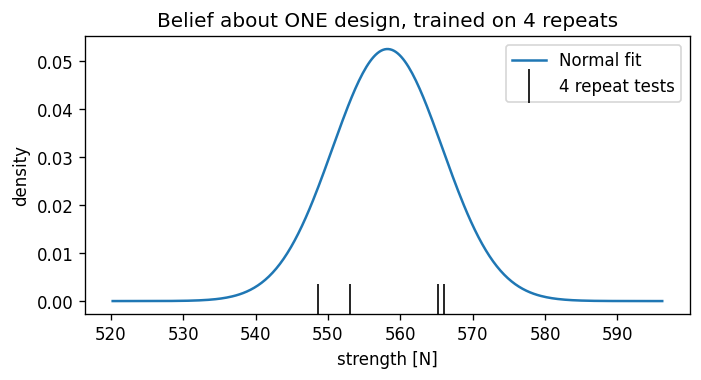

mu = 558.2 N, sigma = 7.6 N  (1.4% relative)
CHECKPOINT: mu = 558.2 N, sigma = 7.6 N -- about 1.4% scatter.
(pandas .std() divides by N-1 and says 8.8 N: with four points, even the
 estimator is an assumption. And this is one geometry on one support
 setup -- pooled over every repeated geometry the campaign scatter runs
 ~4.4%, with session structure inside it. The class works with 3%;
 section 4 stress-tests that choice.)


In [2]:
import scipy.stats as st

# Four repeat prints of ONE design, (b=1.3, H_web=12.8): same fixture, same
# support condition, different print sessions (staff campaign data).
repeats_N = np.array([548.6, 553.0, 565.2, 566.1])

mu_1 = repeats_N.mean()                        # the sample mean, as in ME 239
sigma2_1 = np.mean(repeats_N**2) - mu_1**2     # method of moments
sigma_1 = np.sqrt(sigma2_1)
strength_one_design = st.norm(loc=mu_1, scale=sigma_1)

xs = np.linspace(mu_1 - 5*sigma_1, mu_1 + 5*sigma_1, 300)
plt.figure(figsize=(6.5, 3))
plt.plot(xs, strength_one_design.pdf(xs), label="Normal fit")
plt.plot(repeats_N, np.zeros_like(repeats_N), "k|", ms=20, label="4 repeat tests")
plt.xlabel("strength [N]"); plt.ylabel("density")
plt.title("Belief about ONE design, trained on 4 repeats"); plt.legend()
plt.show()

print(f"mu = {mu_1:.1f} N, sigma = {sigma_1:.1f} N  ({100*sigma_1/mu_1:.1f}% relative)")
print("CHECKPOINT: mu = 558.2 N, sigma = 7.6 N -- about 1.4% scatter.")
print("(pandas .std() divides by N-1 and says 8.8 N: with four points, even the")
print(" estimator is an assumption. And this is one geometry on one support")
print(" setup -- pooled over every repeated geometry the campaign scatter runs")
print(" ~4.4%, with session structure inside it. The class works with 3%;")
print(" section 4 stress-tests that choice.)")

### 0.2 Link two designs with a kernel

The first Normal says nothing about another geometry. A **kernel** converts
distance between designs into correlation. For this warm-up,

$$\rho(d)=\exp\!\left(-\frac{d^2}{2\ell^2}\right).$$

Nearby designs receive larger $\rho$ and therefore share more information.

### 0.3 Condition on one measured beam

Measuring beam A updates beliefs about beams B and C. The size of the update
depends on their kernel correlations with A:

$$\mu_{B\mid A}=\mu_B+\rho\,(a-\mu_A),\qquad
\sigma_{B\mid A}=\sigma_B\sqrt{1-\rho^2}.$$

The round-number prior below is illustrative, and the measurement is treated
as exact for this warm-up. Observation noise returns in section 4.

<details><summary>Optional: where these equations fit</summary>

They are the closed-form conditional mean and standard deviation for two
jointly Gaussian quantities with equal prior standard deviations. They are
Bayes' update specialized to a joint Normal model.

</details>

In [3]:
ell = 2.5                                # length scale, mm -- chosen by hand for now
def corr(d_mm):                          # kernel: distance in, correlation out
    return np.exp(-d_mm**2 / (2*ell**2))

mu_prior, sd_prior = 550.0, 50.0         # illustrative prior belief for B and C
a_measured = 558.2                       # beam A's measured strength [N]

print(f"prior belief about each untested design: N({mu_prior:.0f}, {sd_prior:.0f}^2)\n")
for name, d in [("B, 0.8 mm away", 0.8), ("C, 5.0 mm away", 5.0)]:
    rho = corr(d)
    mu_post = mu_prior + rho*(a_measured - mu_prior)
    sd_post = sd_prior*np.sqrt(1 - rho**2)
    print(f"beam {name}: rho = {rho:.2f}  ->  N({mu_post:.1f}, {sd_post:.1f}^2)")

print("\nMeasuring A nearly settles its neighbor (sigma 50 -> 16 N) and says")
print("almost nothing 5 mm away (sigma 50 -> 49.5 N). The kernel decides how")
print("far one test's information reaches.")

prior belief about each untested design: N(550, 50^2)

beam B, 0.8 mm away: rho = 0.95  ->  N(557.8, 15.6^2)
beam C, 5.0 mm away: rho = 0.14  ->  N(551.1, 49.5^2)

Measuring A nearly settles its neighbor (sigma 50 -> 16 N) and says
almost nothing 5 mm away (sigma 50 -> 49.5 N). The kernel decides how
far one test's information reaches.


### 0.4 Extend the update to many designs

A Gaussian process applies the same conditioning step to a grid of candidate
designs. The compact `numpy` example below uses the thin-web family and varies
only `H_web`, so the result is a one-dimensional strength-to-weight curve with
an uncertainty band. Its length scale, prior spread, and noise are chosen by
hand for this demonstration.

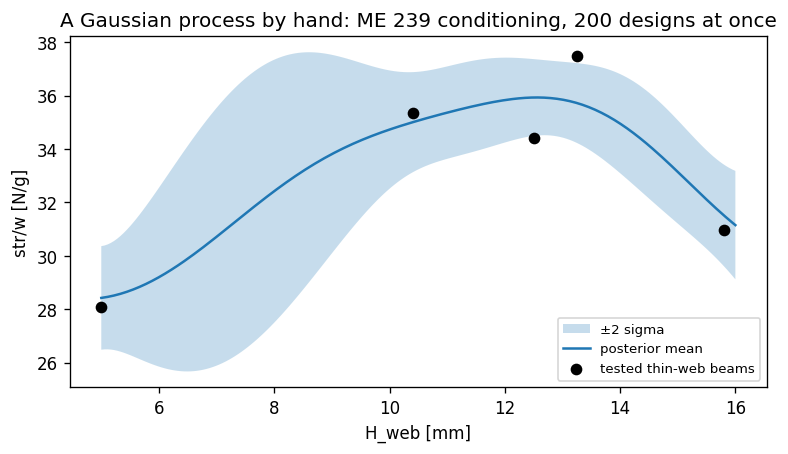

H_web= 8.0 (no tests nearby): mu=32.4 N/g, sigma=2.47
H_web=13.4 (tests nearby):    mu=35.6 N/g, sigma=0.78
The band collapses where beams land and stays wide where nothing was
tested. No failure equation was used -- and no equation gave us a band.


In [4]:
train = df[df.b <= 1.8]                      # thin-web family, incl. the eq query
Ht, yt = train.H.values, train.str_to_weight.values
m0 = yt.mean()                               # prior mean: a constant

ell, sf, sn = 2.5, 4.0, 1.0    # length scale [mm]; prior sd and noise sd [N/g]
def kernel_matrix(H1, H2):
    return sf**2 * np.exp(-(H1[:, None] - H2[None, :])**2 / (2*ell**2))

H_grid = np.linspace(5.0, 16.0, 200)
K = kernel_matrix(Ht, Ht) + sn**2*np.eye(len(Ht))   # tested-vs-tested covariance
Ks = kernel_matrix(Ht, H_grid)                      # tested-vs-grid covariance
w = np.linalg.solve(K, Ks)
mu_post = m0 + w.T @ (yt - m0)                      # the same move as step 3
sd_post = np.sqrt(np.maximum(sf**2 - np.einsum("ij,ij->j", Ks, w), 0.0))

plt.figure(figsize=(7.5, 3.8))
plt.fill_between(H_grid, mu_post - 2*sd_post, mu_post + 2*sd_post, alpha=0.25,
                 label="±2 sigma")
plt.plot(H_grid, mu_post, label="posterior mean")
plt.scatter(Ht, yt, c="black", zorder=3, label="tested thin-web beams")
plt.xlabel("H_web [mm]"); plt.ylabel("str/w [N/g]")
plt.title("A Gaussian process by hand: ME 239 conditioning, 200 designs at once")
plt.legend(fontsize=8); plt.show()

i = np.argmin(abs(H_grid - 8.0)); j = np.argmin(abs(H_grid - 13.4))
print(f"H_web= 8.0 (no tests nearby): mu={mu_post[i]:.1f} N/g, sigma={sd_post[i]:.2f}")
print(f"H_web=13.4 (tests nearby):    mu={mu_post[j]:.1f} N/g, sigma={sd_post[j]:.2f}")
print("The band collapses where beams land and stays wide where nothing was")
print("tested. No failure equation was used -- and no equation gave us a band.")

<details><summary>Optional: what the library implementation adds</summary>

The short cell above is Gaussian process regression. The scikit-learn class
used later adds fitting and bookkeeping around the same conditioning algebra:

- **It tunes the kernel numbers.** We set the length scale, prior sd, and
  noise by hand; sklearn picks the length scale and prior sd by maximizing
  the data's likelihood (`n_restarts_optimizer` restarts that search). The
  noise `alpha` stays *your* assumption — section 4 is about exactly that.
- **Two inputs instead of one.** The kernel distance runs over `(b, H_web)`
  with a separate length scale for each input. This is often called
  **automatic relevance determination (ARD)**.
- **Log target.** The class model fits log(str/w), so its bands read as
  relative (%) errors and its predictions can never cross zero.
- **Standardized inputs.** `b` spans 6 mm and `H_web` spans 11 mm; rescaling
  both to comparable units means one length-scale search does not have to
  undo that imbalance first (fitted scales convert back to mm).

</details>

Two cautions carry forward: every band is conditional on the chosen kernel,
and repeat-to-repeat scatter is different from reducible epistemic
uncertainty. Sections 2 and 4 test those assumptions.

## 1. What choices define a vanilla GP?

*Vanilla* here is a contrast term, not a criticism: this GP learns from the
tested beams alone. Its counterpart is a **physics-informed GP**, which also
gets the Pre-lab 1 failure equations -- as extra input features, or as a
physics baseline whose residual the GP learns. Those versions become lane
options in Submission 1; this pre-lab first establishes what the data-only
model can and cannot do.

A surrogate maps `(b, H_web)` to a performance prediction without using the
failure equations. For a raw target, the GP mean is the central prediction.
For the official log target, `exp(mu_log)` is the posterior median in N/g, not
the arithmetic mean.

- Target: raw str/w or log str/w. Log space makes relative errors and
  multiplicative print scatter more natural.
- Input scale: raw millimeters or standardized coordinates. Scaling changes
  what one numerical unit of distance means to the kernel.
- Kernel: the prior on shape. RBF assumes a very smooth surface; Matérn-5/2
  allows sharper changes. That matters because the minimum of several failure
  capacities can change slope where the governing mode changes.
- Length scales: separate scales let sensitivity to `b` differ from
  sensitivity to `H_web`; one shared scale imposes more structure.
- `alpha`: assumed aleatory observation variance. It is not the GP's
  reducible epistemic uncertainty.

The comparisons below change one choice at a time. None uses physics features.

<details><summary>Optional terminology: ARD</summary>

Separate fitted length scales for each input are often called **automatic
relevance determination (ARD)**. Here the name only means that `b` and
`H_web` receive different length-scale parameters; it does not establish
causal relevance.

</details>

In [5]:
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import ConstantKernel as C, RBF, Matern

X = df[["b", "H"]].values.astype(float)          # the 16 tested designs
sw_obs = df.str_to_weight.values.astype(float)   # ...and their measured str/w
bg = np.linspace(1.0, 7.0, 63); Hg = np.linspace(5.0, 16.0, 60)
BB, HH = np.meshgrid(bg, Hg)                     # dense grid of candidate designs
Xg = np.column_stack([BB.ravel(), HH.ravel()])   # ...as (b, H_web) rows

def fit_vanilla_option(target="log", scale=True, kernel_name="RBF",
                       ard=True, noise=0.03):
    # input-scale choice: standardize (b, H_web), or leave them in raw mm
    fmu = X.mean(0) if scale else np.zeros(2)
    fsd = X.std(0) + 1e-12 if scale else np.ones(2)
    Xfit = (X-fmu)/fsd
    # target choice: learn log(str/w) or raw str/w
    response = np.log(sw_obs) if target == "log" else sw_obs
    ymean = response.mean()        # the GP fits deviations from this constant
    # kernel choice: two separate length scales or one shared; RBF or Matern-5/2
    length0 = [1.0, 1.0] if ard else 1.0
    bounds = (0.1, 30.0) if scale else (0.05, 50.0)
    base = RBF(length0, bounds) if kernel_name == "RBF" else Matern(
        length0, bounds, nu=2.5)
    kernel = C(1.0, (1e-3, 1e3))*base            # C() carries the prior sd
    # noise choice: alpha = assumed aleatory variance -- YOUR assumption
    alpha = noise**2 if target == "log" else (noise*response.mean())**2
    # .fit() is the MLE search for length scales and prior sd (5 restarts)
    gp_ = GaussianProcessRegressor(
        kernel, alpha=alpha, normalize_y=False,
        n_restarts_optimizer=5, random_state=0).fit(Xfit, response-ymean)
    return dict(gp=gp_, fmu=fmu, fsd=fsd, ymean=ymean, target=target,
                scale=scale, kernel_name=kernel_name, ard=ard, noise=noise)

def predict_option(model, Xq):
    # standardize the query the same way, predict, then undo the centering;
    # a log-target prediction maps back to N/g through exp()
    mu, sd = model["gp"].predict(
        (np.asarray(Xq)-model["fmu"])/model["fsd"], return_std=True)
    centered = mu + model["ymean"]
    central_sw = np.exp(centered) if model["target"] == "log" else centered
    return central_sw, sd

def physical_length_scales(model):
    # report fitted length scales in mm, undoing any standardization
    ls = np.atleast_1d(model["gp"].kernel_.k2.length_scale).astype(float)
    if ls.size == 1:
        ls = np.repeat(ls, 2)
    return ls*model["fsd"] if model["scale"] else ls

# five setups: the official recipe, then one changed assumption at a time
OPTION_SPECS = [
    ("official: log, scaled, RBF, separate scales", dict()),
    ("raw target only", dict(target="raw")),
    ("unscaled inputs only", dict(scale=False)),
    ("Matern-5/2 only", dict(kernel_name="Matern")),
    ("shared scale only", dict(ard=False)),
]
option_models = [(name, fit_vanilla_option(**kw)) for name, kw in OPTION_SPECS]
for name, model in option_models:
    print(f"{name}\n  {model['gp'].kernel_}\n"
          f"  physical length scales [b,H] = {physical_length_scales(model).round(3)} mm")


official: log, scaled, RBF, separate scales
  0.0778**2 * RBF(length_scale=[1.7, 0.144])
  physical length scales [b,H] = [3.411 0.476] mm
raw target only
  2.51**2 * RBF(length_scale=[1.59, 0.135])
  physical length scales [b,H] = [3.197 0.446] mm
unscaled inputs only
  0.0778**2 * RBF(length_scale=[3.41, 0.476])
  physical length scales [b,H] = [3.411 0.476] mm
Matern-5/2 only
  0.0793**2 * Matern(length_scale=[2.07, 0.178], nu=2.5)
  physical length scales [b,H] = [4.154 0.586] mm
shared scale only
  0.0749**2 * RBF(length_scale=0.303)
  physical length scales [b,H] = [0.608 0.998] mm


## 2. Compare setup choices on the same axes

These are not five independent truths. They are five posterior surfaces from
the same 16 observations under different modeling assumptions. In these maps
and every design-box map that follows, the **white dots are the 16 tested
beams** — the 15 handout beams plus the class equation query — plotted at
their `(b, H_web)` coordinates. The colored surface between the dots is model
belief, not data.

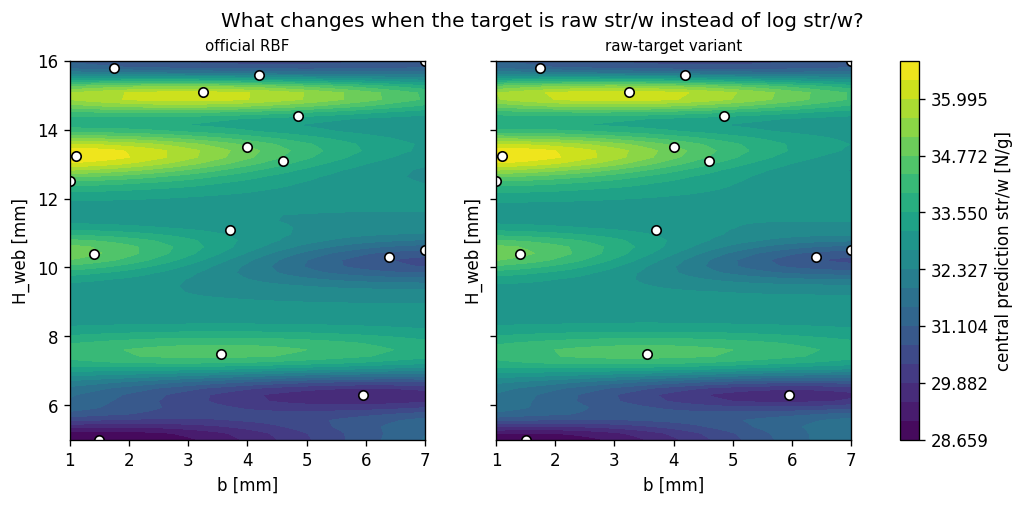

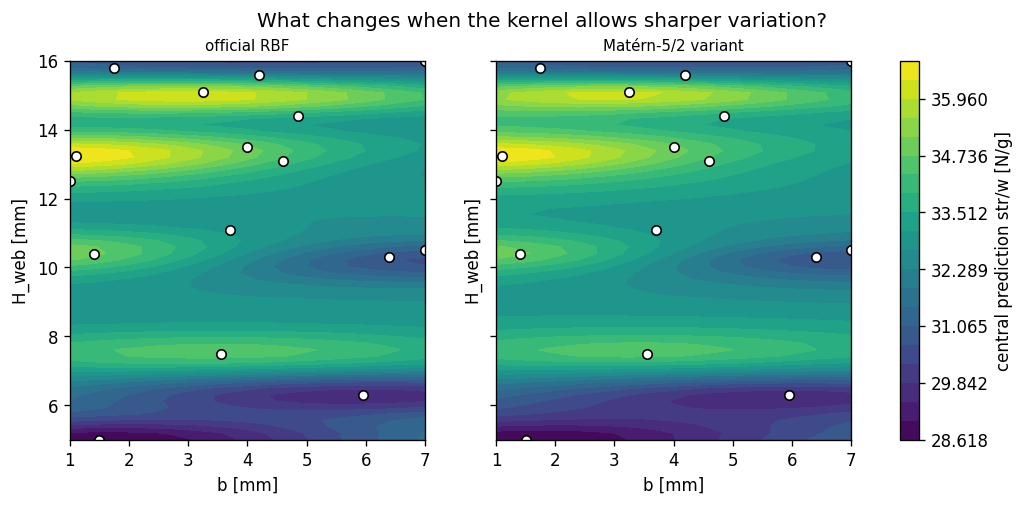

                                      setup   b  H_web  max_prediction
official: log, scaled, RBF, separate scales 1.0  13.20           36.78
                            raw target only 1.0  13.20           36.81
                       unscaled inputs only 1.0  13.20           36.78
                            Matern-5/2 only 1.0  13.20           36.75
                          shared scale only 1.1  13.39           36.65


In [6]:
option_means = [predict_option(model, Xg)[0].reshape(BB.shape)
                for _, model in option_models]
option_lookup = {name: (model, Z) for (name, model), Z
                 in zip(option_models, option_means)}

questions = [
    ("What changes when the target is raw str/w instead of log str/w?",
     "official: log, scaled, RBF, separate scales", "raw target only"),
    ("What changes when the kernel allows sharper variation?",
     "official: log, scaled, RBF, separate scales", "Matern-5/2 only"),
]
for question, left_name, right_name in questions:
    pair = [(left_name, option_lookup[left_name][1]),
            (right_name, option_lookup[right_name][1])]
    short_title = {
        "official: log, scaled, RBF, separate scales": "official RBF",
        "raw target only": "raw-target variant",
        "Matern-5/2 only": "Matérn-5/2 variant",
    }
    lo = min(Z.min() for _, Z in pair); hi = max(Z.max() for _, Z in pair)
    fig, axes = plt.subplots(1, 2, figsize=(10.5, 4.1), sharex=True, sharey=True)
    for ax, (name, Z) in zip(axes, pair):
        cf = ax.contourf(BB, HH, Z, levels=np.linspace(lo, hi, 21),
                         vmin=lo, vmax=hi)
        ax.scatter(df.b, df.H, c="white", edgecolor="black", s=32)
        ax.set_title(short_title.get(name, name), fontsize=9)
        ax.set_xlabel("b [mm]"); ax.set_ylabel("H_web [mm]")
    fig.suptitle(question)
    fig.colorbar(cf, ax=axes.tolist(), label="central prediction str/w [N/g]")
    plt.show()

summary_rows = []
for (name, model), Z in zip(option_models, option_means):
    i = int(np.argmax(Z))
    summary_rows.append(dict(setup=name, b=BB.ravel()[i], H_web=HH.ravel()[i],
                             max_prediction=Z.ravel()[i]))
print(pd.DataFrame(summary_rows).round(2).to_string(index=False))

## 3. Lock the class predictive model

From here onward, reset to the official recipe: standardized `(b,H_web)`, centered
log str/w, RBF with separate length scales, 3% relative noise, fixed optimizer
seed. This keeps the class result reproducible.

fitted official kernel: 0.0778**2 * RBF(length_scale=[1.7, 0.144])
physical length scales: b=3.41 mm, H_web=0.48 mm
checkpoint kernel: roughly 0.0778**2 * RBF(length_scale=[1.7, 0.144])
(Optimizer restarts and sklearn versions wobble these constants in the
 last digits; length scales within a few percent count as matching.)


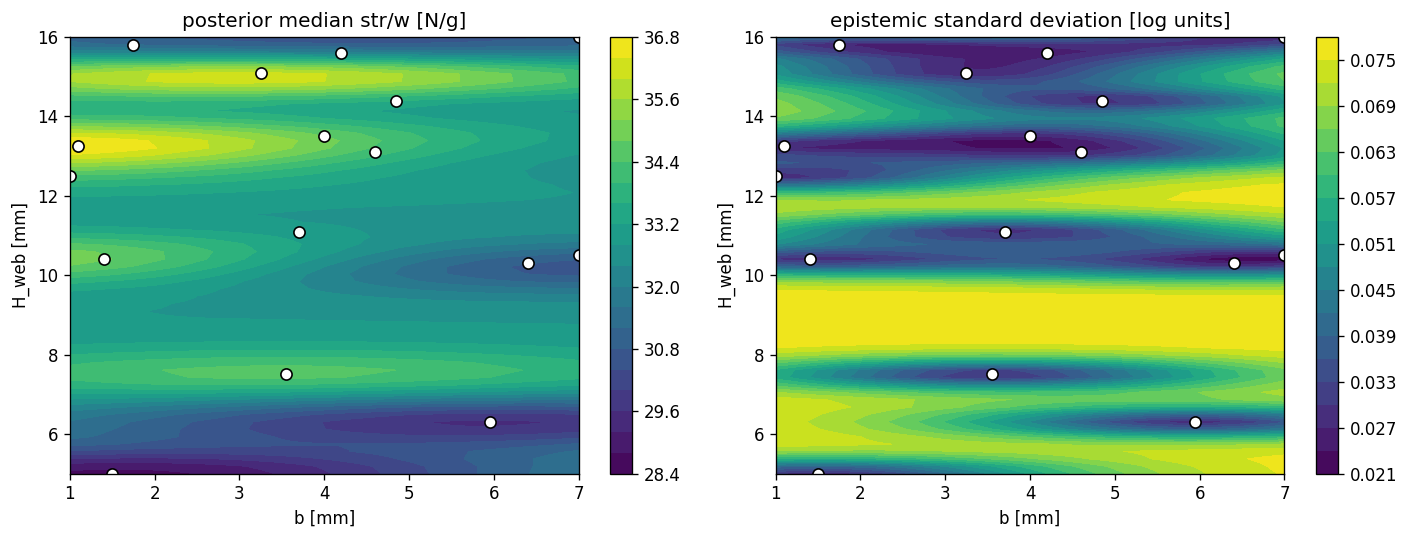

In [7]:
fmu, fsd = X.mean(0), X.std(0) + 1e-12
y = np.log(sw_obs); ymean = y.mean()
def official_kernel():
    return C(1.0, (1e-3, 1e3))*RBF([1.0, 1.0], (1e-1, 30.0))
kernel = official_kernel()
gp = GaussianProcessRegressor(
    kernel, alpha=0.03**2, normalize_y=False,
    n_restarts_optimizer=5, random_state=0).fit((X-fmu)/fsd, y-ymean)
mu_c, std = gp.predict((Xg-fmu)/fsd, return_std=True)
MU = np.exp(mu_c+ymean).reshape(BB.shape)
STD = std.reshape(BB.shape)
ls_std = np.asarray(gp.kernel_.k2.length_scale, float)
ls_mm = ls_std*fsd
print("fitted official kernel:", gp.kernel_)
print(f"physical length scales: b={ls_mm[0]:.2f} mm, H_web={ls_mm[1]:.2f} mm")
print("checkpoint kernel: roughly 0.0778**2 * RBF(length_scale=[1.7, 0.144])")
print("(Optimizer restarts and sklearn versions wobble these constants in the")
print(" last digits; length scales within a few percent count as matching.)")

fig, ax = plt.subplots(1, 2, figsize=(12, 4.6))
for a, Z, title in [(ax[0], MU, "posterior median str/w [N/g]"),
                    (ax[1], STD, "epistemic standard deviation [log units]")]:
    cf = a.contourf(BB, HH, Z, levels=20); fig.colorbar(cf, ax=a)
    a.scatter(df.b, df.H, c="white", edgecolor="black", s=45)
    a.set_xlabel("b [mm]"); a.set_ylabel("H_web [mm]"); a.set_title(title)
plt.tight_layout(); plt.show()

### Read the 2D posterior through two 1D slices

Let $f(b,H)=\ln(S/W)$ be the latent log strength-to-weight trend. The GP gives

$$f(\mathbf{x})\mid\mathcal D\sim
\mathcal N\!\left(\mu_f(\mathbf{x}),\sigma_{epi}^2(\mathbf{x})\right).$$

Epistemic uncertainty describes uncertainty about that latent trend and can
shrink when informative tests are added. A future printed and tested beam also
has independent observation scatter $\epsilon\sim\mathcal N(0,r^2)$:

$$y_*=f(\mathbf{x})+\epsilon,\qquad
\sigma_{total}=\sqrt{\sigma_{epi}^2+r^2},\quad r=0.03.$$

A standard deviation in log space reads as a relative error: $\sigma=0.03$
means roughly ±3% multiplicatively, so $r=0.03$ *is* the class 3% noise
assumption written in log units. $\sigma_{epi}$ shares those units but is a
different quantity — uncertainty about the trend itself, not the scatter of
one test.

The two cuts below cross at the equation-query point. The inner band is
uncertainty about the latent trend; the outer band predicts one future
observation. Both are conditional on the kernel, noise, and model form.

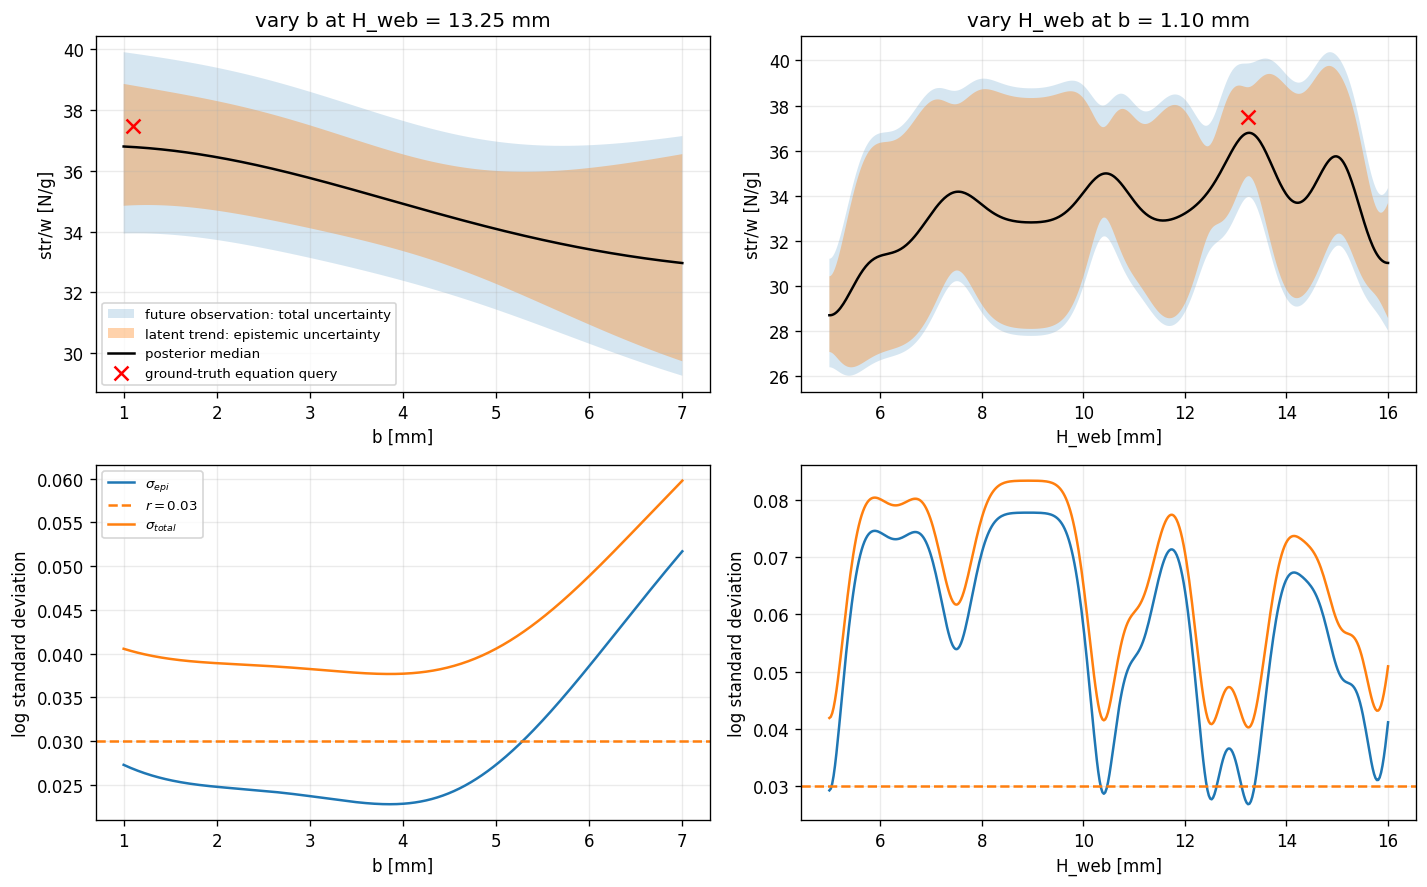

slice crossing: median=36.79 N/g, sigma_epi=0.0268, r=0.0300, sigma_total=0.0402


In [8]:
r_log, z_band = 0.03, 2.0
b_slice = np.linspace(1.0, 7.0, 400)
H_slice = np.linspace(5.0, 16.0, 400)
slices = [
    ("vary b at H_web = 13.25 mm", b_slice,
     np.column_stack([b_slice, np.full_like(b_slice, 13.25)]),
     "b [mm]", 1.10),
    ("vary H_web at b = 1.10 mm", H_slice,
     np.column_stack([np.full_like(H_slice, 1.10), H_slice]),
     "H_web [mm]", 13.25),
]
equation_sw = float(df.loc[df.beam_id.eq(16), "str_to_weight"].iloc[0])
fig, axes = plt.subplots(2, 2, figsize=(12, 7.5))
for col, (title, xplot, Xslice, xlabel, x_anchor) in enumerate(slices):
    mu_slice, sigma_epi = gp.predict((Xslice-fmu)/fsd, return_std=True)
    mu_log = mu_slice + ymean
    median_sw = np.exp(mu_log)
    sigma_total = np.sqrt(sigma_epi**2 + r_log**2)
    lo_epi, hi_epi = (np.exp(mu_log-z_band*sigma_epi),
                      np.exp(mu_log+z_band*sigma_epi))
    lo_total, hi_total = (np.exp(mu_log-z_band*sigma_total),
                          np.exp(mu_log+z_band*sigma_total))
    ax = axes[0, col]
    ax.fill_between(xplot, lo_total, hi_total, alpha=0.18,
                    label="future observation: total uncertainty")
    ax.fill_between(xplot, lo_epi, hi_epi, alpha=0.35,
                    label="latent trend: epistemic uncertainty")
    ax.plot(xplot, median_sw, color="black", label="posterior median")
    ax.scatter(x_anchor, equation_sw, color="red", marker="x", s=70,
               label="ground-truth equation query")
    ax.set(title=title, xlabel=xlabel, ylabel="str/w [N/g]")
    ax.grid(alpha=0.25)
    ax = axes[1, col]
    ax.plot(xplot, sigma_epi, label=r"$\sigma_{epi}$")
    ax.axhline(r_log, color="tab:orange", linestyle="--", label=r"$r=0.03$")
    ax.plot(xplot, sigma_total, label=r"$\sigma_{total}$")
    ax.set(xlabel=xlabel, ylabel="log standard deviation")
    ax.grid(alpha=0.25)
axes[0, 0].legend(fontsize=8)
axes[1, 0].legend(fontsize=8)
plt.tight_layout(); plt.show()

cross = np.array([[1.10, 13.25]])
cross_mu, cross_epi = gp.predict((cross-fmu)/fsd, return_std=True)
cross_total = np.sqrt(cross_epi[0]**2 + r_log**2)
print(f"slice crossing: median={np.exp(cross_mu[0]+ymean):.2f} N/g, "
      f"sigma_epi={cross_epi[0]:.4f}, r={r_log:.4f}, "
      f"sigma_total={cross_total:.4f}")

## 4. Noise: aleatory versus epistemic uncertainty

Refit at 1%, 3%, and 10% assumed relative observation noise. The latent GP
standard deviation is epistemic and can shrink with more informative tests.
Total predictive uncertainty also includes the assumed observation noise:
$\sigma_{total}=\sqrt{\sigma_{epi}^2+r^2}$ in log space.

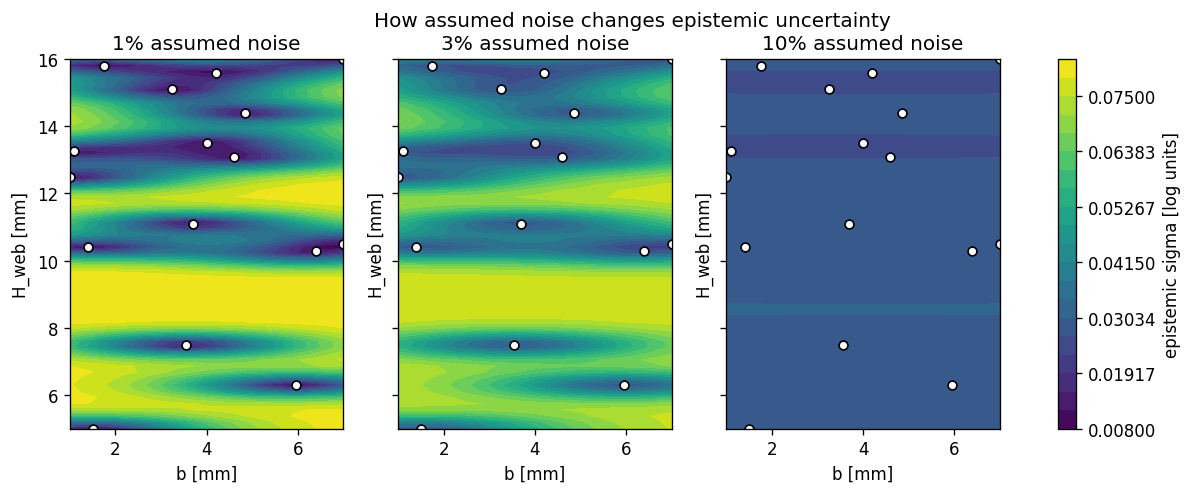

 noise_pct     b  H_web  median_sw  sigma_epistemic  sigma_total
         1 1.581 14.881     36.419            0.048        0.049
         3 1.000 13.390     36.665            0.032        0.044
        10 1.000 13.390     33.500            0.026        0.103

CHECKPOINT: 1% noise recommends (1.58, 14.88), while 3% and 10% recommend (1.00, 13.39). The action is assumption-sensitive: changing alpha changes both the fitted surface and its epistemic uncertainty.


In [9]:
noise_fits, noise_rows, noise_fields = {}, [], {}
for pct in [1, 3, 10]:
    r = pct/100
    g2 = GaussianProcessRegressor(
        official_kernel(), alpha=r**2, normalize_y=False,
        n_restarts_optimizer=5, random_state=0).fit((X-fmu)/fsd, y-ymean)
    m2, s2 = g2.predict((Xg-fmu)/fsd, return_std=True)
    total2 = np.sqrt(s2**2+r**2)
    noise_fits[pct] = (g2, m2, s2)
    noise_fields[pct] = {"epistemic": s2.reshape(BB.shape),
                         "total": total2.reshape(BB.shape)}
    i = int(np.argmax(m2+s2))
    noise_rows.append(dict(noise_pct=pct, b=Xg[i,0], H_web=Xg[i,1],
                           median_sw=np.exp(m2[i]+ymean),
                           sigma_epistemic=s2[i], sigma_total=total2[i]))

# Question: how does the assumed noise change reducible uncertainty? Show only
# epistemic sigma on one shared scale. The table below carries total sigma.
vmin = min(noise_fields[pct]["epistemic"].min() for pct in [1, 3, 10])
vmax = max(noise_fields[pct]["epistemic"].max() for pct in [1, 3, 10])
levels = np.linspace(vmin, vmax, 21)
fig, axes = plt.subplots(1, 3, figsize=(12.5, 4.0), sharex=True, sharey=True)
for ax, pct in zip(axes, [1, 3, 10]):
    Z = noise_fields[pct]["epistemic"]
    cf = ax.contourf(BB, HH, Z, levels=levels, vmin=vmin, vmax=vmax)
    ax.scatter(df.b, df.H, c="white", edgecolor="black", s=28)
    ax.set_title(f"{pct}% assumed noise")
    ax.set_xlabel("b [mm]"); ax.set_ylabel("H_web [mm]")
fig.suptitle("How assumed noise changes epistemic uncertainty")
fig.colorbar(cf, ax=axes.tolist(), label="epistemic sigma [log units]")
plt.show()
print(pd.DataFrame(noise_rows).round(3).to_string(index=False))
print("\nCHECKPOINT: 1% noise recommends (1.58, 14.88), while 3% and 10%"
      " recommend (1.00, 13.39). The action is assumption-sensitive: changing"
      " alpha changes both the fitted surface and its epistemic uncertainty.")

A noise value can be a physical repeatability estimate and a regularization
assumption. If the recommendation moves, the action is model-assumption
sensitive. If it does not, that one decision is locally robust; the noise value
is not thereby proven correct.

Full disclosure on the 3%: pooled over every repeated geometry in the staff
campaign, the estimated print-to-print scatter is closer to **4.4%** — and the
excess over 3% is *structured* (session-to-session and printer-to-printer
drift), not independent per-print noise, which is exactly why no single
percentage is "the" right value. The class fixes 3% as a stated working
assumption. If that bothers you, good: the refits in this section are the
tool for finding out whether your decision actually cares about the
difference. A memo that reruns its design at 4.4% and reports what moved has
done the real check.

## 5. MUI: predicted value plus uncertainty

An **acquisition function** turns the predicted value and epistemic
uncertainty into a next-test score. Maximum Upper Interval uses

$$a_{MUI}=\mu+\psi\sigma.$$

Here $\mu$ is predicted log(str/w), $\sigma$ is epistemic uncertainty, and
$\psi$ controls how strongly uncertainty affects the score. At $\psi=0$,
MUI selects the highest posterior median. Larger values give uncertain
regions more weight, including regions whose median is not competitive.

The worked plot uses $\psi=1$ and marks the design with the highest score.

 psi   b  H_web  median_sw  sigma_epi  score
 0.0 1.0 13.203     36.775      0.028  0.115
 0.5 1.0 13.203     36.775      0.028  0.129
 1.0 1.0 13.390     36.665      0.032  0.143
 2.0 1.0 14.881     35.607      0.055  0.193
 3.0 1.0 14.695     35.022      0.062  0.250


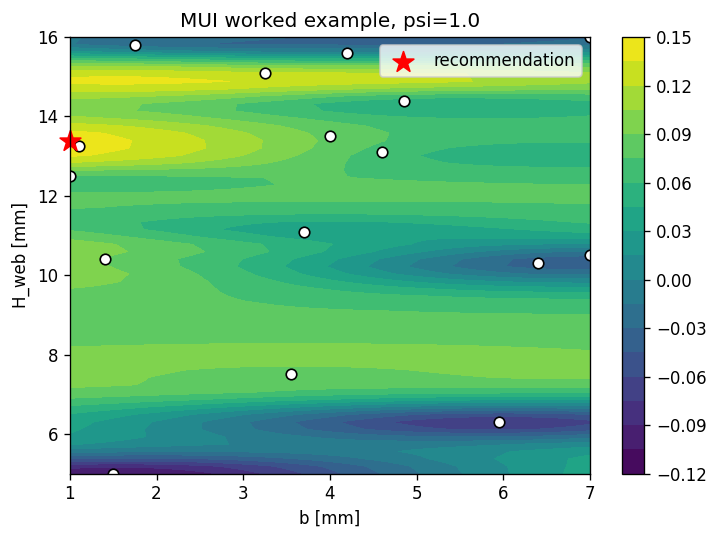

MUI psi=1: b=1.00, H_web=13.39


In [10]:
def mui(mu, sigma, psi):
    return mu + psi*sigma

def recommend_mui(psi, mu=mu_c, sigma=std):
    acq = mui(mu, sigma, psi)
    i = int(np.argmax(acq))
    return Xg[i], np.exp(mu[i]+ymean), sigma[i], acq[i]

mui_rows = []
for psi in [0.0, 0.5, 1.0, 2.0, 3.0]:
    x, median, sig, acq = recommend_mui(psi)
    mui_rows.append(dict(psi=psi, b=x[0], H_web=x[1],
                         median_sw=median, sigma_epi=sig, score=acq))
print(pd.DataFrame(mui_rows).round(3).to_string(index=False))

psi_show = 1.0
mui_surface = mui(mu_c, std, psi_show).reshape(BB.shape)
x_mui, _, _, _ = recommend_mui(psi_show)
fig, ax = plt.subplots(figsize=(6.2, 4.6))
cf = ax.contourf(BB, HH, mui_surface, levels=20); fig.colorbar(cf, ax=ax)
ax.scatter(df.b, df.H, c="white", edgecolor="black", s=40)
ax.scatter(*x_mui, c="red", marker="*", s=170, label="recommendation",
           clip_on=False)
ax.set(xlabel="b [mm]", ylabel="H_web [mm]",
       title=f"MUI worked example, psi={psi_show}")
ax.legend(); plt.tight_layout(); plt.show()
print(f"MUI psi=1: b={x_mui[0]:.2f}, H_web={x_mui[1]:.2f}")

## 6. EI: expected gain over the best tested beam

**Expected Improvement (EI)** asks how much a new test is expected to beat
the best tested beam so far, $y_{best}$. Results below that reference count
as zero improvement; results above it count by their margin:

$$EI=(\mu-y_{best}-\xi)\Phi(Z)+\sigma\phi(Z),\quad
Z=\frac{\mu-y_{best}-\xi}{\sigma},$$

where $\Phi$ and $\phi$ are the standard Normal CDF and PDF. The margin
$\xi$ raises the amount a result must beat $y_{best}$ before it counts.
Increasing $\xi$ often favors less-certain regions, but does not guarantee a
more exploratory recommendation. The worked plot uses $\xi=0.01$.

<details><summary>Optional: derivation and implementation notes</summary>

The formula is the posterior expectation of
$\max(Y-y_{best}-\xi,0)$ for a Normal $Y$. Both MUI and EI are evaluated in
centered log(str/w) space over the full design box, so a tested design may be
recommended again when observation noise is present. For a 1D derivation,
see [Lecture 23 of Ilias Bilionis's Introduction to Scientific Machine
Learning](https://predictivesciencelab.github.io/data-analytics-se/lecture23/intro.html).

</details>

   xi   b  H_web  median_sw  sigma_epi  score
0.000 1.0 14.881     35.607      0.055  0.005
0.005 1.0 14.881     35.607      0.055  0.004
0.010 1.0 14.881     35.607      0.055  0.004
0.030 1.0 14.881     35.607      0.055  0.002
0.050 1.0 14.881     35.607      0.055  0.001


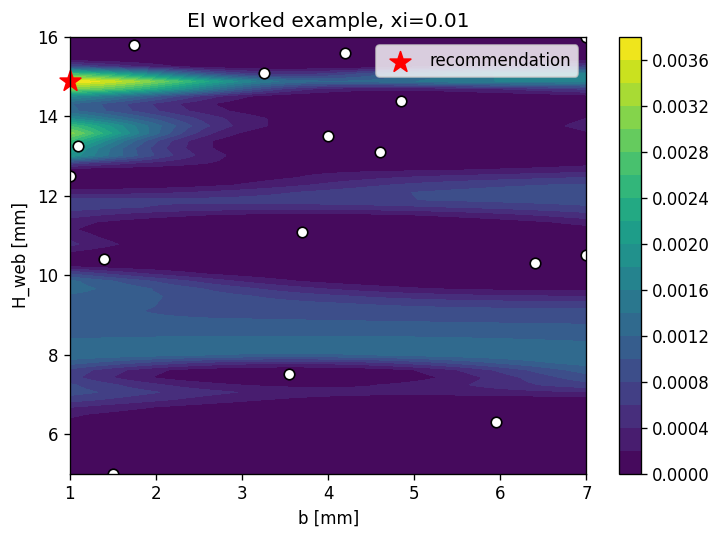

EI xi=.01: b=1.00, H_web=14.88
EI checkpoint: b=1.00, H_web=14.88.


In [11]:
from scipy.stats import norm

y_best = np.log(df.str_to_weight).max()-ymean
def ei(mu, sigma, xi=0.0):
    imp = mu - y_best - xi
    safe = np.maximum(sigma, 1e-12)
    Z = imp/safe
    return np.where(sigma > 1e-12,
                    imp*norm.cdf(Z)+sigma*norm.pdf(Z), 0.0)

def recommend_ei(xi, mu=mu_c, sigma=std):
    acq = ei(mu, sigma, xi)
    i = int(np.argmax(acq))
    return Xg[i], np.exp(mu[i]+ymean), sigma[i], acq[i]

ei_rows = []
for xi in [0.0, 0.005, 0.01, 0.03, 0.05]:
    x, median, sig, acq = recommend_ei(xi)
    ei_rows.append(dict(xi=xi, b=x[0], H_web=x[1],
                        median_sw=median, sigma_epi=sig, score=acq))
print(pd.DataFrame(ei_rows).round(3).to_string(index=False))

xi_show = 0.01
ei_surface = ei(mu_c, std, xi_show).reshape(BB.shape)
x_ei, _, _, _ = recommend_ei(xi_show)
fig, ax = plt.subplots(figsize=(6.2, 4.6))
cf = ax.contourf(BB, HH, ei_surface, levels=20); fig.colorbar(cf, ax=ax)
ax.scatter(df.b, df.H, c="white", edgecolor="black", s=40)
ax.scatter(*x_ei, c="red", marker="*", s=170, label="recommendation",
           clip_on=False)
ax.set(xlabel="b [mm]", ylabel="H_web [mm]",
       title=f"EI worked example, xi={xi_show}")
ax.legend(); plt.tight_layout(); plt.show()
print(f"EI xi=.01: b={x_ei[0]:.2f}, H_web={x_ei[1]:.2f}")
print("EI checkpoint: b=1.00, H_web=14.88.")

### Read a boundary recommendation

Before moving on, notice *where* the worked examples put their stars:
b = 1.00 is not an interior point. It is the boundary of the design box — an edge the class box was
only recently widened to include, with exactly one tested beam on it
(beam 15). A boundary recommendation carries a message an interior one does
not: the acquisition surface was still rising when it reached the boundary, so the
model would keep going left if the box allowed it. Treat edge picks — and
corner picks doubly, where two walls meet — as higher-risk by default. At an
edge the data is one-sided (every tested neighbor sits on the same side);
one step past it, the prediction is pure kernel assumption. Box edges are
also where physical extremes concentrate — the thinnest printable web, the
lightest section (H_web = 16 minimizes mass at any b) — and extremes are
where new failure modes switch on: the handout's flange-web separation notes
cluster in exactly this thin-b family (beams 12, 14, and 15). None of this
forbids an edge design. It raises the burden of proof, and Submission 1 will
ask you to carry it using nearby evidence, a physics argument, or a clear
statement that the test is intended to reduce uncertainty.

## 7. Final filter: the one class GP design

You explored alternatives, but the class query must be reproducible: locking
one recipe is what makes the second ground-truth query a single shared data point
that every group can compare. The final rule is fixed: official RBF model
with separate input length scales,
3% noise, MUI with $\psi=1$, on the stated grid. No exclusion rule is
needed: the widened box leaves the model a genuinely untested thin-b strip,
and the upper interval goes there on its own. (Had it instead picked a
tested point, re-measuring under noise is a defensible spend — it would
just be a different lesson.) Your own settings take over in Submission 1,
where the design — and the print — are yours.

In [12]:
x_class, mean_class, sigma_class, _ = recommend_mui(1.0)
print(f"LOCKED CLASS DESIGN: b={x_class[0]:.2f} mm, H_web={x_class[1]:.2f} mm")
print(f"posterior median={mean_class:.1f} N/g, epistemic sigma_log={sigma_class:.3f}")
print("CHECKPOINT: b=1.00, H_web=13.39, predicted 36.7 N/g.")

LOCKED CLASS DESIGN: b=1.00 mm, H_web=13.39 mm
posterior median=36.7 N/g, epistemic sigma_log=0.032
CHECKPOINT: b=1.00, H_web=13.39, predicted 36.7 N/g.


In [13]:
assert abs(x_class[0]-1.00) < 0.06
assert abs(x_class[1]-13.39) < 0.06

## KEY-only sensitivity comparison

The official model remains the class rule. The next cell only shows what
regularizing the sparse length-scale problem would change.

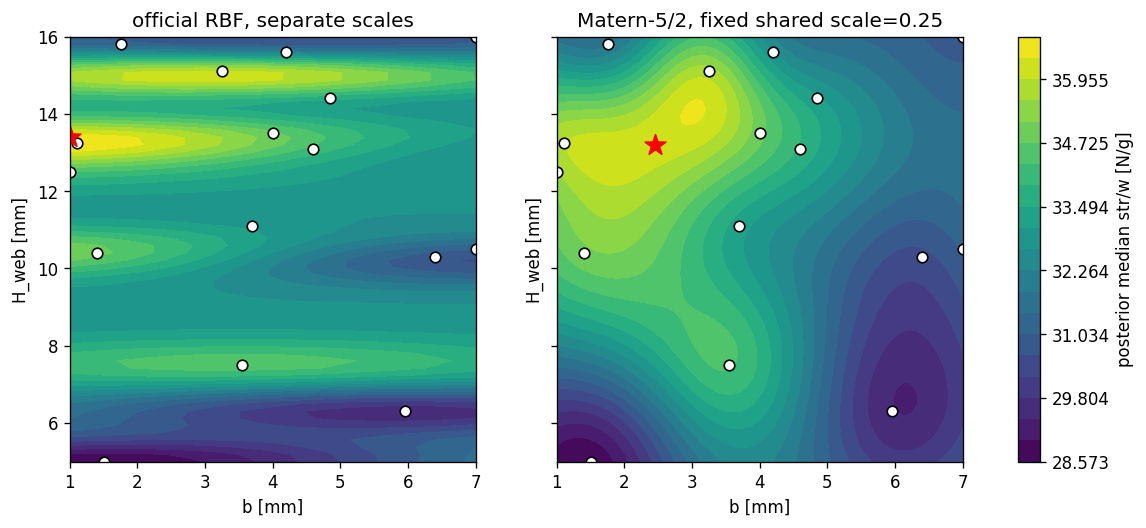

official MUI psi=1 recommendation: (1.0, 13.39)
regularized Matern recommendation: (2.45, 13.2)
This comparison changes kernel and length-scale regularization; it is not the class recommendation.


In [14]:
matern_fixed = GaussianProcessRegressor(
    C(1.0, (1e-3, 1e3))*Matern(
        length_scale=0.25, length_scale_bounds="fixed", nu=2.5),
    alpha=0.03**2, normalize_y=False,
    n_restarts_optimizer=5, random_state=0).fit(
        (X-np.array([1.0, 5.0]))/np.array([6.0, 11.0]), y-ymean)
mm, ss = matern_fixed.predict(
    (Xg-np.array([1.0, 5.0]))/np.array([6.0, 11.0]), return_std=True)
surfaces = [MU, np.exp(mm+ymean).reshape(BB.shape)]
im = int(np.argmax(mm+ss))
x_matern = Xg[im]
lo = min(z.min() for z in surfaces); hi = max(z.max() for z in surfaces)
fig, axes = plt.subplots(1, 2, figsize=(12, 4.6), sharex=True, sharey=True)
for ax, Z, title, xrec in zip(
        axes, surfaces,
        ["official RBF, separate scales", "Matern-5/2, fixed shared scale=0.25"],
        [x_class, x_matern]):
    cf = ax.contourf(BB, HH, Z, levels=np.linspace(lo, hi, 21), vmin=lo, vmax=hi)
    ax.scatter(df.b, df.H, c="white", edgecolor="black", s=40)
    ax.scatter(*xrec, c="red", marker="*", s=170)
    ax.set_xlabel("b [mm]"); ax.set_ylabel("H_web [mm]"); ax.set_title(title)
fig.colorbar(cf, ax=axes.ravel().tolist(), label="posterior median str/w [N/g]")
plt.show()
print(f"official MUI psi=1 recommendation: {tuple(np.round(x_class, 2))}")
print(f"regularized Matern recommendation: {tuple(np.round(x_matern, 2))}")
print("This comparison changes kernel and length-scale regularization; it is not the class recommendation.")

## Memo questions

Answer these in markdown cells at the end of this notebook — they are graded
with the notebook when it is turned in alongside Submission 1, and they do not
go in the Submission 1 memo.

1. Cite one region where epistemic uncertainty changes the action relative to
   maximizing the posterior median alone. Use the median, epistemic-sigma, and
   acquisition maps.
2. Compare at least two vanilla setup choices from section 2. Which assumption
   changed the surface, and why is that not evidence that one is automatically true?
3. Compare MUI and EI. Do they recommend the same design, and what does each dial value?
4. Why does the locked GP design differ from the equation design, and why is
   their agreement on the thin-b region weaker evidence than it looks? What
   do the failure notes contain that neither scalar-response model uses?
5. Explain whether the noise activity makes the locked recommendation robust
   or assumption-sensitive.

No new design code is required. The final submitted class design is
`(b=1.00, H_web=13.39)` from the locked cell.

## KEY: memo targets

1. Accept any map-supported region where a larger epistemic sigma changes the
   acquisition ranking relative to median-only exploitation.
2. Students should identify the one changed assumption and use the printed
   kernels/length scales or common-scale maps as evidence. Sparse-data MLE can
   support materially different surfaces.
3. MUI adds a sigma bonus everywhere; EI weights the probability and amount of
   beating the incumbent. The recommendation table supplies exact comparisons.
4. The equation maximizes its calibrated capacity/mass. The locked GP maximizes
   a data-conditioned upper interval -- conditioned on data that already
   contains the equation beam's result, so the two class beams agreeing on
   the thin-b region is conditioning, not independent convergence. Note also
   where the GP pick sits: on the b = 1.0 boundary, the geometry family where
   beams 12, 14, and 15 all separated at the flange-web interface. Failure
   morphology, layer separation, fixture tipping, and fracture progression
   are absent from both scalar targets.
5. Use the generated 1/3/10% table. The 1% fit recommends (1.58, 14.88), while
   the 3% and 10% fits recommend (1.00, 13.39), direct evidence that this action
   is sensitive to the assumed noise and the surface it regularizes.